# Model Explainability

The objective of this notebook is to interpret the machine learning results and identify the clinical biomarkers that contribute most strongly to pancreatic cancer detection.
Explainability is particularly important in healthcare applications because it helps translate predictive performance into clinically meaningful insights.

## Data Loading

The pancreatic cancer dataset is loaded and prepared for explainability analysis.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/pancreatic_600_risk123.csv")

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

df["sex"].value_counts()

df["sex_encoded"] = (
    df["sex"]
    .map({
        "M": 1,
        "F": 0
    })
)


X = df[
    [
        "age",
        "sex_encoded",
        "plasma_C",
        "creatinine",
        "LYVE1",
        "REG1B",
        "TFF1",
        "REG1A",
        "CA19_9",
        "CEA",
        "bilirubin",
        "glucose",
        "urine_volume",
        "urine_pH"
    ]
]

y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(
    X_train_scaled,
    y_train
)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

## Logistic Regression Coefficients

The magnitude of the standardized logistic regression coefficients is used to identify the biomarkers that contribute most strongly to model predictions.

In [9]:
coef_df = pd.DataFrame(
    log_reg.coef_.T,
    index=X.columns,
    columns=[
        "Healthy",
        "Benign",
        "Cancer"
    ]
)

coef_df

,Healthy,Benign,Cancer
age,-0.125628,0.013251,0.112377
sex_encoded,0.115983,-0.161245,0.045262
plasma_C,-1.413412,-0.117419,1.530831
creatinine,-0.532527,-0.081947,0.614474
LYVE1,-1.156901,-0.002872,1.159773
REG1B,-1.594617,0.097684,1.496933
TFF1,-1.091066,-0.008435,1.099501
REG1A,-1.956865,0.411113,1.545751
CA19_9,-0.402993,-0.730394,1.133386
CEA,-0.815659,-0.216366,1.032025


In [10]:
cancer_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coef_df["Cancer"].abs()
})

cancer_importance = (
    cancer_importance
    .sort_values(
        by="Coefficient",
        ascending=False
    )
)

cancer_importance

,Feature,Coefficient
REG1A,REG1A,1.545751
plasma_C,plasma_C,1.530831
REG1B,REG1B,1.496933
bilirubin,bilirubin,1.201810
LYVE1,LYVE1,1.159773
CA19_9,CA19_9,1.133386
TFF1,TFF1,1.099501
CEA,CEA,1.032025
creatinine,creatinine,0.614474
urine_volume,urine_volume,0.256407


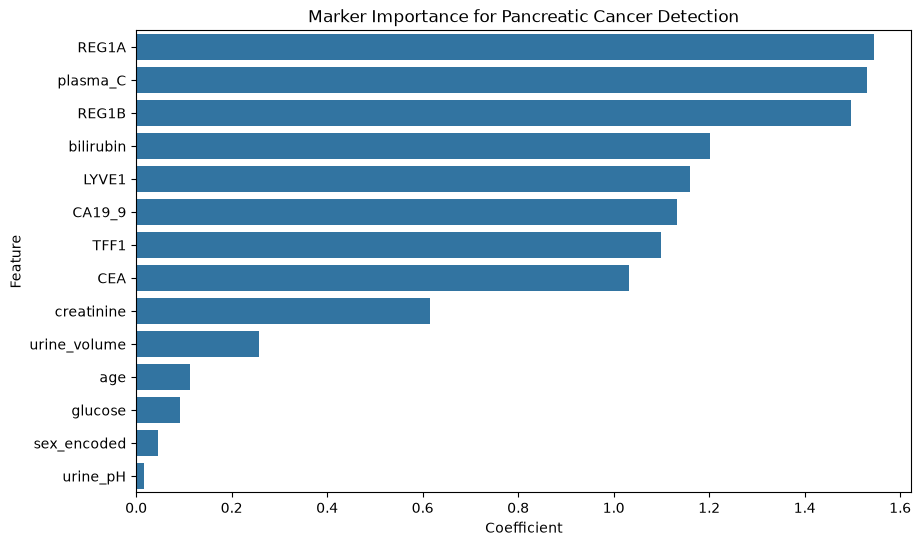

In [12]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=cancer_importance,
    x="Coefficient",
    y="Feature"
)

plt.title(
    "Marker Importance for Pancreatic Cancer Detection"
)

plt.show()

### Findings

Several biomarkers consistently emerged as the strongest contributors to pancreatic cancer classification.
REG1A, REG1B, plasma_C, CA19-9, TFF1, CEA, LYVE1 and bilirubin received the largest coefficient magnitudes in the Logistic Regression model, indicating a strong influence on cancer prediction.
The demographic variable sex was also included in the analysis. However, its coefficient magnitude was substantially smaller than those of the biomarker variables, suggesting that predictive performance is primarily driven by biological measurements rather than demographic characteristics within this dataset.
The consistency of these findings across exploratory analysis, statistical validation and machine learning modelling increases confidence in their potential clinical relevance.

## Comparison with Random Forest Feature Importance

The markers identified by Logistic Regression are compared with the Random Forest feature importance rankings obtained during the modelling stage.

### Findings

The explainability results obtained from Logistic Regression were broadly consistent with the Random Forest feature importance rankings.
REG1A, REG1B, plasma_C, CA19-9, TFF1 and CEA repeatedly appeared among the most influential variables across both modelling approaches.
In contrast, sex contributed relatively little predictive information, despite being included in the final modelling dataset.
The agreement between these independent modelling techniques strengthens confidence in the relevance of the identified biomarker panel for pancreatic cancer classification.

## Conclusions

Pancreatic cancer is particularly challenging to detect because symptoms frequently appear only after the disease has progressed to later stages.
Model explainability analysis revealed that a relatively small group of biomarkers contributes most strongly to pancreatic cancer detection.
REG1A, REG1B, plasma_C, CA19-9, TFF1, CEA, LYVE1 and bilirubin consistently emerged as influential features across exploratory analysis, statistical validation, Random Forest feature importance and Logistic Regression coefficient analysis.
The demographic variable sex was evaluated throughout the analysis but demonstrated limited predictive influence compared with the biomarker panel.
Combined with the modelling results, which achieved 97.5% accuracy and 100% recall for pancreatic cancer cases using Logistic Regression, these findings suggest that machine learning models can provide both strong predictive performance and clinically interpretable insights into the biological markers associated with pancreatic cancer diagnosis.